In [ ]:
!pip install shap

In [132]:
import ee
import math
import geemap
import pprint
import datetime
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict
from statistics import mean, pstdev
import matplotlib.dates as mdates

ee.Authenticate
ee.Initialize(project='toribiodiego-ece471')

# Homework 2
- ECE471: Fundamentals of Remote Sensing and Earth Observation
- Spring 2025
- Instructor: Krishna Karra
- Contact: krishna.karra@cooper.edu (Teams chat is quickest)
- Assigned: Wednesday, February 26, 2025
- Due: Tuesday, March 18, 2025 (by midnight EST)

## Problem Motivation

The United States Department of Agriculture (USDA), in conjunction with the United States Geological Survey (USGS), produces the Cropland Data Layer (CDL), an annual landcover map of crop types across the Continental United States at 30-meter resolution. This map, which incorporates Landsat and Sentinel imagery from across the year, represents some of the highest quality, rigorously validated land cover classification that can be found anywhere.

A year's annual map is usually released a few months into the next year (e.g. the 2020 CDL is released towards the end of the first quarter of 2021). As a geospatial consultant, your task is to investigate whether certain crop types could be predicted *in-season* (e.g. without using a full year's worth of imagery).

The CDL is used within government and industry for crop health monitoring, crop area estimation, agricultural policy development, environmental monitoring, yield forecasting and more. In-season prediction of crop types would be vastly useful for all of these applications.

For this pilot study, the focus will be on Iowa and Illinois.

## Problem Overview

The overall workflow will be:

1. Analyze cropland data to identify the 5 most prevalent crops grown in Iowa and Illinois.
2. Explore and visualize the seasonal patterns of those 5 crops using vegetation index time series analysis.
3. Develop a crop identification model that takes satellite imagery as input and predicts crop type at the pixel level.
4. Assess model performance using validation data and metrics.
5. Apply the model to full counties to produce crop type maps and compare against ground truth data.

The core data sources will be:

1. Cropland Data Layer (CDL) for crop type ground truth labels
2. Landsat satellite imagery for model inputs
3. Google Earth Engine (GEE) platform for analysis and modeling

This assignment will give you real, concrete experience with:

- Working with large-scale geospatial data
- Time series analysis of vegetation indices
- Developing and validating a remote sensing model
- Creating meaningful data visualizations and maps

Your modeling approach and additional data sources are flexible. The key deliverables are: ranked crop list, crop seasonal analysis, trained crop identification model, model evaluations, and final county-level crop maps.

## Task 1: Identify Most Prevalent Crops

###*Goal: Plan to have made significant progress on Task 1 (or completed it) by March 5.*

The goal of this task is to create a ranked list of the most commonly grown crops across Iowa and Illinois based on acreage data from the 2019 Cropland Data Layer (CDL).

Specifically, you should:

1. Load the 2019 CDL raster data for the 2 states from Google Earth Engine.
2. Write a script to calculate the total acreage of each unique crop type in the CDL legend across the 2 states.
3. Rank the crops based on total acreage from most to least.
4. Output the list as a CSV file with two columns: Crop Name and Total Acres. Include the top 20 crops. Include the top 20 crops.
5. From this list, select the top 5 most prevalent crops. These will be the focus for the rest of the analysis.

Things to keep in mind:

1. Analysis must be done programmatically using GEE.
2. Output must be a clean CSV file with the columns specified.
3. Make sure to handle any data filtering or preprocessing steps like reprojections.
4. Document your methodology and thought process

### 1.0 - Helper Functions

In [133]:
def compute_crop_acreage_table(
    region,
    crop_legend,
    area_name=None,
    verbose=False,
    top5=False,
    global_stats=False,
    produce_top20_csv=False,
):
    """
    Compute crop acreage statistics for the given region using the 2019 USDA CDL.
    Returns a formatted table (string) with Rank, Crop Code, Crop Name, Total Acres, and % of total.
    Optionally prints global stats and exports a CSV for the top 20 crops.
    """
    # Load the 2019 CDL image.
    cdl_2019 = ee.Image("USDA/NASS/CDL/2019")

    # Calculate total area in the region in acres.
    area_image = ee.Image.pixelArea().multiply(0.000247105)
    total_area_stats = area_image.reduceRegion(
        reducer=ee.Reducer.sum(), geometry=region, scale=30, maxPixels=1e13
    )
    total_area_in_acres = total_area_stats.getInfo().get("area", 0)

    # Combine the area image with the CDL cropland band.
    combined_image = area_image.addBands(cdl_2019.select("cropland"))

    # Sum area by crop code.
    reducer = ee.Reducer.sum().group(groupField=1, groupName="crop_code")
    stats = combined_image.reduceRegion(
        reducer=reducer, geometry=region, scale=30, maxPixels=1e13
    )
    groups = stats.get("groups")
    if groups is None:
        return "No crop data found for this region."
    groups = groups.getInfo()

    # Prepare per-crop data.
    table_data = []
    total_crop_acres = sum(entry["sum"] for entry in groups)
    for entry in groups:
        crop_code = entry["crop_code"]
        acreage = entry["sum"]
        crop_name = crop_legend.get(crop_code, "Unknown")
        pct_crops = (acreage / total_crop_acres) * 100 if total_crop_acres else 0
        table_data.append(
            {
                "Code": crop_code,
                "Name": crop_name,
                "Total": round(acreage),
                "Area (%)": round(pct_crops),
            }
        )

    # Sort by Total Acres descending and add rank.
    table_data_sorted = sorted(table_data, key=lambda x: x["Total"], reverse=True)
    for idx, row in enumerate(table_data_sorted, start=1):
        row["Rank"] = idx

    final_data = []
    for row in table_data_sorted:
        final_data.append(
            {
                "Rank": row["Rank"],
                "Code": row["Code"],
                "Name": row["Name"],
                "Total": row["Total"],
                "%": row["Area (%)"],
            }
        )

    # Format data for display.
    display_data = []
    for row in final_data:
        new_row = row.copy()
        new_row["Total"] = format(row["Total"], ",")
        for word in ["Intensity", "Space"]:
            new_row["Name"] = new_row["Name"].replace(word, "")
        new_row["Name"] = new_row["Name"].strip()
        display_data.append(new_row)

    data_to_print = display_data if verbose or not top5 else display_data[:5]
    table_str = tabulate(data_to_print, headers="keys", tablefmt="grid")

    # Print global stats if requested.
    if global_stats:
        unique_crops = len(final_data)
        global_stats_data = [
            {
                "# Unique Crops": unique_crops,
                "Total Area": format(round(total_area_in_acres), ","),
            }
        ]
        global_stats_table = tabulate(
            global_stats_data, headers="keys", tablefmt="grid"
        )
        table_str = table_str + "\n" + global_stats_table

    # Export CSV for top 20 crops if requested.
    if produce_top20_csv:
        csv_filename = (
            f"{area_name}_top20_crops.csv" if area_name else "top20_crops.csv"
        )
        df = pd.DataFrame(final_data)
        df_top20 = df.sort_values(by="Total", ascending=False).head(20)
        df_top20 = df_top20[["Name", "Total"]]
        df_top20.to_csv(csv_filename, index=False)
        print(f"[INFO] CSV file saved as: {csv_filename}")

    return table_str


def get_state_geometry(state_abbr_list):
    """
    Return a combined ee.Geometry for the states provided.
    """
    states = ee.FeatureCollection("TIGER/2018/States")
    fc_filtered = states.filter(ee.Filter.inList("STUSPS", state_abbr_list))
    return fc_filtered.geometry()


def get_county_geometry(state_fips, county_name):
    """
    Retrieve the ee.Geometry for a county given its state FIPS and county name.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    county_fc = counties.filter(ee.Filter.eq("STATEFP", state_fips)).filter(
        ee.Filter.eq("NAME", county_name)
    )
    return county_fc.first().geometry()


def get_county_spread(state_fips, verbose=True):
    """
    Return (smallest, median, largest) counties for a given state (by FIPS code) based on acreage.
    Prints a summary table if verbose=True.
    """
    counties = ee.FeatureCollection("TIGER/2018/Counties").filter(
        ee.Filter.eq("STATEFP", state_fips)
    )
    counties_info = counties.getInfo()["features"]
    sqm_to_acres = 0.000247105
    county_land_area = []
    for f in counties_info:
        props = f["properties"]
        name = props["NAME"]
        acres = props["ALAND"] * sqm_to_acres
        county_land_area.append((name, round(acres)))
    county_land_area.sort(key=lambda x: x[1])
    smallest = county_land_area[0]
    largest = county_land_area[-1]
    mid_idx = len(county_land_area) // 2
    median = county_land_area[mid_idx]

    if verbose:
        spread_data = [
            {
                "Type": "Smallest",
                "County Name": smallest[0],
                "Acreage": format(smallest[1], ","),
            },
            {
                "Type": "Median",
                "County Name": median[0],
                "Acreage": format(median[1], ","),
            },
            {
                "Type": "Largest",
                "County Name": largest[0],
                "Acreage": format(largest[1], ","),
            },
        ]
        print(tabulate(spread_data, headers="keys", tablefmt="grid"))

    return smallest, median, largest

### 1.1 - Rectangular Region (Central Iowa)

In [ ]:
# define a small rectangular geometry (e.g., in Central Iowa)
test_region = ee.Geometry.Rectangle([-93.75, 41.6, -93.6, 41.7])

# load the 2019 CDL image and build a crop legend
cdl_2019 = ee.Image("USDA/NASS/CDL/2019")

crop_class_names = cdl_2019.get("cropland_class_names").getInfo()
crop_class_values = cdl_2019.get("cropland_class_values").getInfo()

# if properties are strings, convert them to lists
if isinstance(crop_class_names, str):
    crop_class_names = crop_class_names.split(",")

if isinstance(crop_class_values, str):
    crop_class_values = [int(val) for val in crop_class_values.split(",")]
crop_legend = dict(zip(crop_class_values, crop_class_names))

# compute the crop acreage table for the test region
table_str = compute_crop_acreage_table(
    region=test_region,
    crop_legend=crop_legend,
    area_name="test_rectangle",
    verbose=False,
    top5=True,  # print top 5
    global_stats=True,  # print global statistics
    produce_top20_csv=False,
)


print(table_str)
print(
    "\n\033[1mTable 1\033[0m. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa)."
)


+--------+--------+----------------+---------+-----+
|   Rank |   Code | Name           | Total   |   % |
+========+========+================+=========+=====+
|      1 |    122 | Developed/Low  | 11,224  |  33 |
+--------+--------+----------------+---------+-----+
|      2 |    121 | Developed/Open | 6,810   |  20 |
+--------+--------+----------------+---------+-----+
|      3 |    123 | Developed/Med  | 3,931   |  11 |
+--------+--------+----------------+---------+-----+
|      4 |    190 | Woody Wetlands | 2,124   |   6 |
+--------+--------+----------------+---------+-----+
|      5 |    176 | Grass/Pasture  | 2,032   |   6 |
+--------+--------+----------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               24 | 34,299       |
+------------------+--------------+

Table 1. Crop Acreage Table (top 5) with global statistics for the small test region (Central Iowa).


### 1.2 - Iowa County Spread

In [ ]:
# get the smallest, median, and largest counties by land area.
smallest_county, median_county, largest_county = get_county_spread(state_fips="19")

# retrieve the geometries for each.
smallest_geom = get_county_geometry("19", smallest_county[0])
median_geom = get_county_geometry("19", median_county[0])
largest_geom = get_county_geometry("19", largest_county[0])

#### 1.2.1 - Smallest County

In [ ]:
table_small = compute_crop_acreage_table(
    region=smallest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_smallest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_small)
print(
    "\n\033[1mTable 2\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's smallest county (Dickinson)."
)

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 94,176  |  36 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 76,273  |  30 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 25,505  |  10 |
+--------+--------+---------------------+---------+-----+
|      4 |    195 | Herbaceous Wetlands | 17,314  |   7 |
+--------+--------+---------------------+---------+-----+
|      5 |    111 | Open Water          | 15,564  |   6 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               30 | 258,535      |
+------------------+--------------+

Table 2. Crop Acreage Table (top 5) with global statistics for Io

#### 1.2.2 - Median County

In [ ]:
table_median = compute_crop_acreage_table(
    region=median_geom,
    crop_legend=crop_legend,
    area_name="Iowa_median_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_median)
print(
    "\n\033[1mTable 3\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene)."
)

+--------+--------+------------------+---------+-----+
|   Rank |   Code | Name             | Total   |   % |
+========+========+==================+=========+=====+
|      1 |      1 | Corn             | 177,537 |  49 |
+--------+--------+------------------+---------+-----+
|      2 |      5 | Soybeans         | 120,595 |  33 |
+--------+--------+------------------+---------+-----+
|      3 |    176 | Grass/Pasture    | 23,398  |   6 |
+--------+--------+------------------+---------+-----+
|      4 |    121 | Developed/Open   | 13,267  |   4 |
+--------+--------+------------------+---------+-----+
|      5 |    141 | Deciduous Forest | 11,484  |   3 |
+--------+--------+------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               28 | 365,611      |
+------------------+--------------+

Table 3. Crop Acreage Table (top 5) with global statistics for Iowa's median county (Greene).


#### 1.2.3 - Largest County

In [ ]:
table_large = compute_crop_acreage_table(
    region=largest_geom,
    crop_legend=crop_legend,
    area_name="Iowa_largest_county",
    verbose=False,
    top5=True,
    global_stats=True,
    produce_top20_csv=False,
)
print(table_large)
print(
    "\n\033[1mTable 4\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa's largest county (Kossuth)."
)

+--------+--------+---------------------+---------+-----+
|   Rank |   Code | Name                | Total   |   % |
+========+========+=====================+=========+=====+
|      1 |      1 | Corn                | 317,292 |  51 |
+--------+--------+---------------------+---------+-----+
|      2 |      5 | Soybeans            | 205,863 |  33 |
+--------+--------+---------------------+---------+-----+
|      3 |    176 | Grass/Pasture       | 32,508  |   5 |
+--------+--------+---------------------+---------+-----+
|      4 |    121 | Developed/Open      | 21,438  |   3 |
+--------+--------+---------------------+---------+-----+
|      5 |    195 | Herbaceous Wetlands | 14,077  |   2 |
+--------+--------+---------------------+---------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               31 | 623,565      |
+------------------+--------------+

Table 4. Crop Acreage Table (top 5) with global statistics for Io

### 1.3 - Iowa and Illinois

In [ ]:
# create a combined geometry for Iowa + Illinois
ia_il_geometry = get_state_geometry(["IA", "IL"])

# demonstrates producing a CSV with top 20 crops (useful for Task 1).
table_ia_il = compute_crop_acreage_table(
    region=ia_il_geometry,
    crop_legend=crop_legend,
    area_name="Iowa_Illinois",  # name the CSV "Iowa_Illinois_top20_crops.csv"
    verbose=False,  # do not print every crop
    top5=True,  # limit to top 5
    global_stats=True,  # print region-level stats
    produce_top20_csv=True,  # generate CSV of top 20 crops
)
print(table_ia_il)
print(
    "\n\033[1mTable 5\033[0m. Crop Acreage Table (top 5) with global statistics for Iowa + Illinois."
)

[INFO] CSV file saved as: Iowa_Illinois_top20_crops.csv
+--------+--------+------------------+------------+-----+
|   Rank |   Code | Name             | Total      |   % |
+========+========+==================+============+=====+
|      1 |      1 | Corn             | 24,044,494 |  33 |
+--------+--------+------------------+------------+-----+
|      2 |      5 | Soybeans         | 18,860,571 |  26 |
+--------+--------+------------------+------------+-----+
|      3 |    141 | Deciduous Forest | 7,935,511  |  11 |
+--------+--------+------------------+------------+-----+
|      4 |    176 | Grass/Pasture    | 7,378,873  |  10 |
+--------+--------+------------------+------------+-----+
|      5 |    121 | Developed/Open   | 2,690,743  |   4 |
+--------+--------+------------------+------------+-----+
+------------------+--------------+
|   # Unique Crops | Total Area   |
+==================+==============+
|               66 | 73,078,611   |
+------------------+--------------+

Table 6. 

## Task 2: Crop Seasonal Analysis

###*Goal: Plan to have made significant progress by March 5*

Goal: Analyze the seasonal patterns of the top 5 crops using vegetation index time series.

Overview:

1. Sample pixels growing for each crop across the two states
2. Compute NDVI time series for each crop sample
3. Generate visualizations of the NDVI curves
4. Perform additional analysis on crop emergence, harvest dates, etc (optional)

This will reveal unique temporal signatures of the crops and inform model development.

### 2.0 - Helper Functions

In [131]:
# Initialize Earth Engine.
ee.Initialize()

# Define top 5 crops
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

# 2.1) Grid Creation and Crop Sampling
def create_grid(region, cell_size):
    """
    Create a grid of square cells (as Features) covering the given region.
    :param region: ee.Geometry defining the region.
    :param cell_size: cell size in meters.
    :return: ee.FeatureCollection of grid cells.
    """
    bounds = region.bounds()
    coords = ee.List(ee.List(bounds.coordinates().get(0)))
    lons = coords.map(lambda pt: ee.Number(ee.List(pt).get(0)))
    lats = coords.map(lambda pt: ee.Number(ee.List(pt).get(1)))
    min_lon = ee.Number(lons.reduce(ee.Reducer.min()))
    max_lon = ee.Number(lons.reduce(ee.Reducer.max()))
    min_lat = ee.Number(lats.reduce(ee.Reducer.min()))
    max_lat = ee.Number(lats.reduce(ee.Reducer.max()))

    # Approx degrees for cell_size (1 deg ~ 111 km)
    cell_deg = ee.Number(cell_size).divide(111000)

    # Create lists of lon/lat values for grid lines
    lon_list = ee.List.sequence(min_lon, max_lon, cell_deg)
    lat_list = ee.List.sequence(min_lat, max_lat, cell_deg)

    def make_cell(lon):
        def make_cell_inner(lat):
            cell = ee.Geometry.Rectangle([
                lon, lat,
                ee.Number(lon).add(cell_deg),
                ee.Number(lat).add(cell_deg)
            ])
            return ee.Feature(cell)
        return lat_list.map(make_cell_inner)

    grid = lon_list.map(make_cell)
    grid = ee.FeatureCollection(ee.List(grid).flatten())
    return grid

def sample_crop_locations(
    cdl_image,
    crop_code,
    crop_name,
    region_geom,
    num_points
):
    """
    Revised to use stratified sampling with ee.Image.stratifiedSample,
    ensuring we get exactly num_points for the specified crop_code.
    """
    # We'll sample from the CDL "cropland" band by specifying classValues=[crop_code].
    # The 'exact' parameter forces the algorithm to get the requested sample size
    # unless the class area is too small.
    samples = cdl_image.stratifiedSample(
        numPoints=0,               # This is ignored when classValues/classPoints is used.
        classBand='cropland',      # The band in cdl_image to stratify by (already named "cropland").
        region=region_geom,
        scale=30,
        classValues=[crop_code],
        classPoints=[num_points],
        seed=42,
        geometries=True,
        dropNulls=True
    )
    return samples


# 1. Cloud Masking for Landsat SR
def mask_landsat_clouds_sr(image):
    qa_pixel = image.select('QA_PIXEL')
    cloud_bit = 1 << 3
    shadow_bit = 1 << 4
    snow_bit = 1 << 5
    water_bit = 1 << 7
    mask = (qa_pixel.bitwiseAnd(cloud_bit).eq(0)
            .And(qa_pixel.bitwiseAnd(shadow_bit).eq(0))
            .And(qa_pixel.bitwiseAnd(snow_bit).eq(0))
            .And(qa_pixel.bitwiseAnd(water_bit).eq(0)))
    return image.updateMask(mask)

# 2. NDVI Computation for Landsat 8/9 SR
def add_ndvi(image):
    ndvi = image.expression(
        '(NIR - RED) / (NIR + RED)',
        {
            'NIR': image.select('SR_B5').multiply(0.0000275).add(-0.2),
            'RED': image.select('SR_B4').multiply(0.0000275).add(-0.2),
        }
    ).rename('NDVI')
    return image.addBands(ndvi)

# 3. Build Landsat NDVI Collection
def get_landsat_ndvi_collection(start_date='2019-01-01', end_date='2019-12-31', region=None):
    l8_sr = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterDate(start_date, end_date)
    if region:
        l8_sr = l8_sr.filterBounds(region)
    l8_sr = l8_sr.map(mask_landsat_clouds_sr).map(add_ndvi)
    return l8_sr.select(["NDVI", "QA_PIXEL"])

# 4. Extract NDVI Time Series from Sample Points
def extract_ndvi_time_series(ndvi_collection, sample_points):
    def per_image(image):
        date_str = image.date().format('YYYY-MM-dd')
        sampled = image.select("NDVI").sampleRegions(
            collection=sample_points,
            scale=30,
            geometries=True
        ).map(lambda f: f.set("date", date_str))
        return sampled
    return ndvi_collection.map(per_image).flatten()

# 5. Aggregate NDVI by Date (Daily)
def aggregate_ndvi_by_date(timeseries_fc):
    fc_list = timeseries_fc.toList(timeseries_fc.size()).getInfo()
    data_by_date = defaultdict(list)
    for feat in fc_list:
        props = feat['properties']
        date_str = props.get('date')
        ndvi_val = props.get('NDVI')
        if date_str is not None and ndvi_val is not None:
            data_by_date[date_str].append(ndvi_val)
    results = []
    for date_str, ndvi_vals in data_by_date.items():
        if len(ndvi_vals) < 1:
            continue
        results.append({
            'date': date_str,
            'mean_ndvi': mean(ndvi_vals),
            'std_dev': pstdev(ndvi_vals),
            'count': len(ndvi_vals)
        })
    results.sort(key=lambda x: x['date'])
    return results

# 6. Plot NDVI Time Series (Daily)
def plot_ndvi_time_series(ndvi_stats, title="NDVI Time Series"):
    if len(ndvi_stats) == 0:
        print("No NDVI data to plot.")
        return
    dates = [datetime.strptime(e['date'], '%Y-%m-%d') for e in ndvi_stats]
    means = [e['mean_ndvi'] for e in ndvi_stats]
    stdevs = [e['std_dev'] for e in ndvi_stats]
    plus_1sigma = [m + s for m, s in zip(means, stdevs)]
    minus_1sigma = [m - s for m, s in zip(means, stdevs)]
    plus_2sigma = [m + 2*s for m, s in zip(means, stdevs)]
    minus_2sigma = [m - 2*s for m, s in zip(means, stdevs)]
    plt.figure(figsize=(8, 5))
    plt.fill_between(dates, minus_2sigma, plus_2sigma, alpha=0.1, label='±2σ')
    plt.fill_between(dates, minus_1sigma, plus_1sigma, alpha=0.2, label='±1σ')
    plt.plot(dates, means, label='Mean NDVI')
    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('NDVI')
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
    plt.show()

# 7. County Geometry and Spread (Simplified)
def get_county_geometry(state_fips, county_name):
    counties = ee.FeatureCollection("TIGER/2018/Counties")
    county_fc = counties.filter(ee.Filter.eq('STATEFP', state_fips)) \
                        .filter(ee.Filter.eq('NAME', county_name))
    return county_fc.first().geometry()

def get_county_spread(state_fips, verbose=True):
    counties = ee.FeatureCollection("TIGER/2018/Counties").filter(ee.Filter.eq('STATEFP', state_fips))
    counties_info = counties.getInfo()['features']
    sqm_to_acres = 0.000247105
    county_land_area = []
    for f in counties_info:
        props = f['properties']
        name = props['NAME']
        acres = props['ALAND'] * sqm_to_acres
        county_land_area.append((name, round(acres)))
    county_land_area.sort(key=lambda x: x[1])
    smallest = county_land_area[0]
    median = county_land_area[len(county_land_area)//2]
    largest = county_land_area[-1]
    if verbose:
        table = [["Smallest", smallest[0]], ["Median", median[0]], ["Largest", largest[0]]]
        print(tabulate(table, headers=["Type", "County"], tablefmt="grid"))
    return smallest, median, largest

# 8. Process Top 5 Crops for a Given Geometry
def process_top5_crops(input_geom, top_5_crops, year='2019', region_name="Region", verbose=True):
    cdl_image = ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(input_geom)
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    ndvi_collection = get_landsat_ndvi_collection(start_date, end_date, input_geom)
    for crop_code, crop_name in top_5_crops.items():
        sample_fc = sample_crop_locations(
            cdl_image=cdl_image,
            crop_code=crop_code,
            crop_name=crop_name,
            region_geom=input_geom,
            num_points=250,
        )
        ndvi_ts = extract_ndvi_time_series(ndvi_collection, sample_fc)
        agg_data = aggregate_ndvi_by_date(ndvi_ts)
        if verbose and agg_data:
            table_rows = [{"Date": row['date'],
                           "Mean NDVI": f"{row['mean_ndvi']:.4f}",
                           "Std Dev": f"{row['std_dev']:.4f}",
                           "Count": row['count']} for row in agg_data]
            print(tabulate(table_rows, headers="keys", tablefmt="grid"))
        title = f"{crop_name}"
        plot_ndvi_time_series(agg_data, title=title)

# Note: sample_crop_locations is assumed to be defined elsewhere (or already revised)
# 9. Export NDVI Time Series Asset
def export_ndvi_timeseries_asset(fc, crop_name, region_name, year='2019'):
    safe_crop_name = crop_name.replace(" ", "_").replace("/", "_")
    asset_id = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{region_name}_{safe_crop_name}_{year}"
    description = f"Asset_NDVI_TS_{region_name}_{safe_crop_name}_{year}"
    task = ee.batch.Export.table.toAsset(
        collection=fc,
        description=description,
        assetId=asset_id,
        fileFormat='CSV'
    )
    task.start()
    print(f"Export to asset started for {crop_name} in {region_name} for {year}. Asset ID: {asset_id}")

# 10. Load EE Asset to Python List
def load_ee_asset_to_list(asset_id):
    fc = ee.FeatureCollection(asset_id)
    fc_info = fc.getInfo()
    features = fc_info.get('features', [])
    return [feat['properties'] for feat in features]

# 11. Aggregate NDVI Monthly from Daily Data
def aggregate_ndvi_monthly(ndvi_data):
    data_by_month = defaultdict(list)
    for entry in ndvi_data:
        date_str = entry.get('date')
        ndvi_val = entry.get('mean_ndvi')
        if date_str and ndvi_val is not None:
            dt = datetime.strptime(date_str, '%Y-%m-%d')
            ym = (dt.year, dt.month)
            data_by_month[ym].append(ndvi_val)
    monthly_results = []
    for (yr, mo), ndvi_vals in data_by_month.items():
        if not ndvi_vals:
            continue
        monthly_results.append({
            'date': datetime(yr, mo, 1).strftime('%Y-%m-%d'),
            'mean_ndvi': mean(ndvi_vals),
            'std_dev': pstdev(ndvi_vals) if len(ndvi_vals) > 1 else 0,
            'count': len(ndvi_vals)
        })
    monthly_results.sort(key=lambda x: x['date'])
    return monthly_results

# 12. Plot NDVI Time Series from a Python List (Monthly)
def plot_ndvi_time_series_from_list(ndvi_stats, title="NDVI Time Series"):
    if not ndvi_stats:
        print("No NDVI data to plot.")
        return
    dates = [datetime.strptime(entry['date'], '%Y-%m-%d') for entry in ndvi_stats]
    means = [entry['mean_ndvi'] for entry in ndvi_stats]
    stdevs = [entry['std_dev'] for entry in ndvi_stats]
    plus_1sigma = [m + s for m, s in zip(means, stdevs)]
    minus_1sigma = [m - s for m, s in zip(means, stdevs)]
    plus_2sigma = [m + 2*s for m, s in zip(means, stdevs)]
    minus_2sigma = [m - 2*s for m, s in zip(means, stdevs)]
    plt.figure(figsize=(8, 5))
    plt.fill_between(dates, minus_2sigma, plus_2sigma, alpha=0.1, label='±2σ')
    plt.fill_between(dates, minus_1sigma, plus_1sigma, alpha=0.2, label='±1σ')
    plt.plot(dates, means, marker='o', label='Mean NDVI')
    plt.title(title)
    plt.xlabel('Month')
    plt.ylabel('NDVI')
    plt.legend()
    plt.grid(True)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m'))
    plt.show()



### Task 2.1: Sample Crop Pixel Locations

- Write a script to randomly sample at least 250 pixel locations for each of the 5 crops.
- Spread the sampling across the 2 states to capture geographical diversity.
- Output the sampled points as a FeatureCollection in GEE.
- Visualize the points to ensure they look as expected.
- Document your sampling methodology (e.g. spatial filters, randomization, etc.)
- The sampling script should be modular to allow increasing the sampling size.

#### 2.1.2 - Smallest County (Iowa)

In [ ]:
# Specify state and county (for example: Iowa, Dickinson)
state_fips = '19'
county_name = 'Dickinson'  # single county name

# Get county geometry
county_geom = get_county_geometry(state_fips, county_name)

# Clip the CDL image (2019) to the county geometry
cdl_image = ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(county_geom)

# Define a color mapping for each crop
crop_colors = {
    "Corn": "red",
    "Soybeans": "blue",
    "Deciduous Forest": "green",
    "Grass/Pasture": "yellow",
    "Developed/Open Space": "magenta"
}

# Create an interactive map for the county
center = county_geom.centroid().coordinates().getInfo()[::-1]  # [lat, lon]
m_county = geemap.Map(center=center, zoom=11)
m_county.addLayer(county_geom, {"color": "grey", "fillColor": "00000000"}, f"{county_name} Geometry")

# Sample points for each of the top 5 crops in the county and add each as a layer with its designated color
for crop_code, crop_name in top_5_crops.items():
    samples = sample_crop_locations(
        cdl_image, crop_code, crop_name, county_geom,
        num_points=250,  # adjust sample size as needed
    )
    # Retrieve the color for the current crop, defaulting to red if not found
    color = crop_colors.get(crop_name, "red")
    m_county.addLayer(samples, {"color": color}, f"Samples: {crop_name}")

m_county.addLayerControl()
m_county


Map(center=[43.37798452295224, -95.15082718314032], controls=(WidgetControl(options=['position', 'transparent_…

#### 2.1.3 - Iowa and Illinois

In [ ]:
# Get Iowa geometry using get_state_geometry.
iowa_geom = get_state_geometry(['IA'])
region_name = "Iowa"

# Create the Landsat NDVI collection for Iowa.
ndvi_collection = get_landsat_ndvi_collection(start_date, end_date, iowa_geom)

# Loop over each of the top 5 crops.
for crop_code, crop_name in top_5_crops.items():
    print(f"\nProcessing crop: {crop_name} (Code: {crop_code})")

    # Sample crop locations for the current crop in Iowa.
    sample_fc = sample_crop_locations(
        cdl_image=ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(iowa_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=iowa_geom,
        num_points=250,
    )

    # Extract the NDVI time series for the sampled points.
    ndvi_ts = extract_ndvi_time_series(ndvi_collection, sample_fc)

    # Aggregate the NDVI values by date.
    agg_data = aggregate_ndvi_by_date(ndvi_ts)

    # Convert the aggregated data (a Python list) into an EE FeatureCollection,
    # assigning a dummy geometry (Point at [0, 0]) to each feature.
    features = [ee.Feature(ee.Geometry.Point([0, 0]), row) for row in agg_data]
    agg_fc = ee.FeatureCollection(features)

    # Set up an asynchronous export of the aggregated NDVI time series as an EE asset.
    export_ndvi_timeseries_asset(agg_fc, crop_name, region_name, year='2019')

In [ ]:
# Dictionary of asset IDs for each crop.
asset_ids = {
    "Corn": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Corn_2019",
    "Soybeans": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Soybeans_2019",
    "Deciduous_Forest": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Deciduous_Forest_2019",
    "Grass_Pasture": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Grass_Pasture_2019",
    "Developed_Open_Space": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Developed_Open_Space_2019"
}

# Loop over each asset (crop), load data, aggregate monthly, and plot
for crop, asset_id in asset_ids.items():
    print(f"Loading asset for {crop}...")
    daily_ndvi_data = load_ee_asset_to_list(asset_id)

    # Convert daily data to monthly aggregates (optional but usually cleaner)
    monthly_ndvi_data = aggregate_ndvi_monthly(daily_ndvi_data)

    # Plot the monthly NDVI time series
    plot_title = f"NDVI Time Series for {crop} in Iowa (2019)"

### Task 2.2: Calculate NDVI Time Series

- For each crop, use the sampled points to extract NDVI values over a full year.
- Use all available Landsat surface reflectance imagery from 2019.
- Handle clouds/shadows by filtering out low quality NDVI values.
- Calculate the mean, 1-sigma, and 2-sigma NDVI curves for each crop across the time series.
- Plot the NDVI curves with date on x-axis and NDVI on y-axis.
- Include the crop name, number of sample points, and time range in the plot.
- Document your approach for filtering, aggregating, and plotting the time series data.

Key requirements:

- Use GEE reducers to extract NDVI values per pixel.
- Make sure to mask clouds and filter low quality NDVI.
- Plot mean, 1-sigma, and 2-sigma to show variability across many samples
- Output clean, labeled, and informative plots.

#### 2.2.1 - Helper Functions

#### 2.2.2 - Largest County (Iowa)

In this section, we process the NDVI time series for the largest county in Iowa as an initial test. By focusing on a single, large county, we can verify that our sampling, NDVI extraction, and aggregation functions work as expected on a smaller scale. This pilot analysis helps us identify any potential issues with our approach—such as performance bottlenecks—before scaling up to larger areas.


Figure 1. NDVI Time Series for Top 5 Crops in Kossuth (2019)


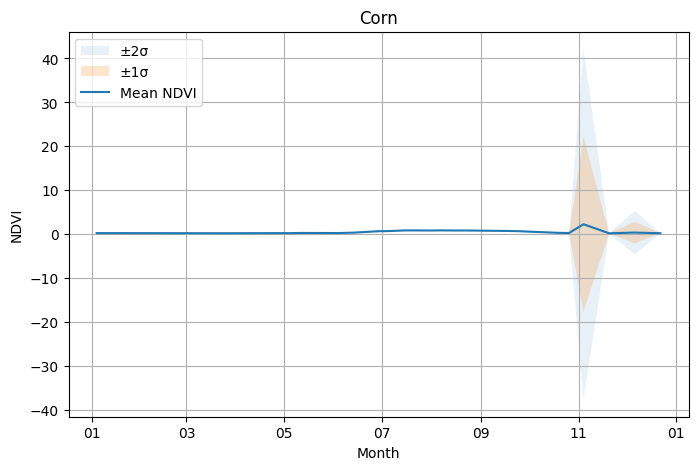

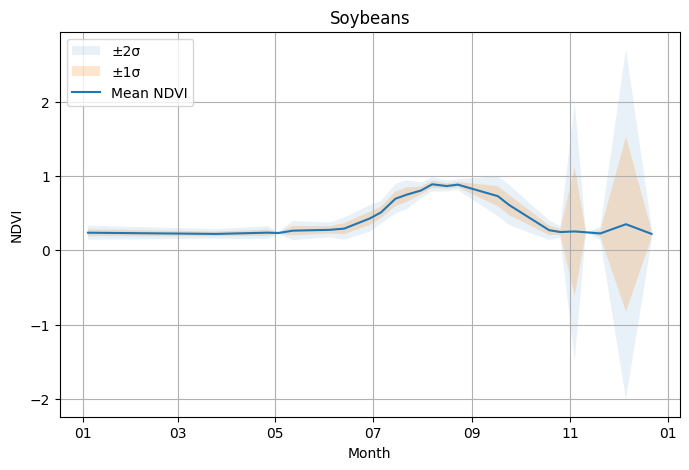

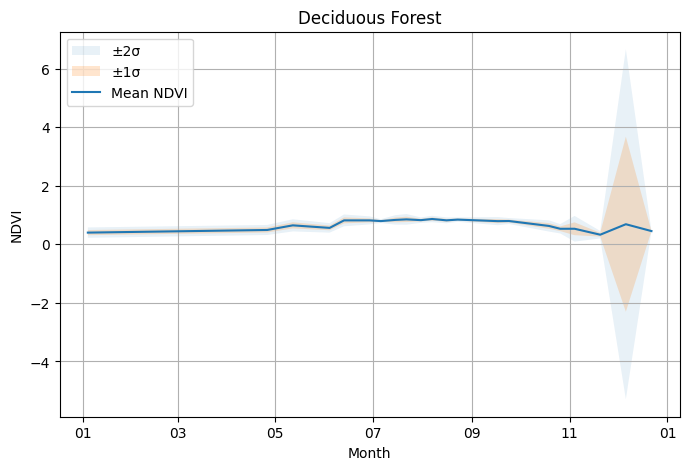

In [ ]:
state_fips = '19'
smallest, median, largest = get_county_spread(state_fips, verbose=False)
largest_county_name = largest[0]

# get the county geometry for the largest county
county_geom = get_county_geometry(state_fips, largest_county_name)

# process the top 5 crops for this county.
print("\n\033[1mFigure 1\033[0m. NDVI Time Series for Top 5 Crops in Kossuth (2019)")
process_top5_crops(county_geom, top_5_crops, year='2019', region_name=largest_county_name, verbose=False)

#### 2.2.3 - Iowa and Illinois

**Scaling Up:** Exporting NDVI Time Series as Assets for Larger Regions

For state-wide analyses, such as in Iowa and Illinois, the increased data volume (with each crop requiring about 250 samples) can lead to timeouts when processed directly. To address this, we export the aggregated NDVI time series as Earth Engine assets. This approach offloads the heavy computations to Earth Engine’s infrastructure, allowing us to load the pre-processed assets later for aggregation and plotting. Scaling up from a single county to entire states also helped us understand and manage the computational challenges that arise with larger regions.


In [ ]:
# Get Iowa geometry using get_state_geometry.
iowa_geom = get_state_geometry(['IA'])
region_name = "Iowa"

# Create the Landsat NDVI collection for Iowa.
ndvi_collection = get_landsat_ndvi_collection(start_date, end_date, iowa_geom)

# Loop over each of the top 5 crops.
for crop_code, crop_name in top_5_crops.items():
    print(f"\nProcessing crop: {crop_name} (Code: {crop_code})")

    # Sample crop locations for the current crop in Iowa.
    sample_fc = sample_crop_locations(
        cdl_image=ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(iowa_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=iowa_geom,
        num_points=250,
    )

    # Extract the NDVI time series for the sampled points.
    ndvi_ts = extract_ndvi_time_series(ndvi_collection, sample_fc)

    # Aggregate the NDVI values by date.
    agg_data = aggregate_ndvi_by_date(ndvi_ts)

    # Convert the aggregated data (a Python list) into an EE FeatureCollection,
    # assigning a dummy geometry (Point at [0, 0]) to each feature.
    features = [ee.Feature(ee.Geometry.Point([0, 0]), row) for row in agg_data]
    agg_fc = ee.FeatureCollection(features)

    # Set up an asynchronous export of the aggregated NDVI time series as an EE asset.
    export_ndvi_timeseries_asset(agg_fc, crop_name, region_name, year='2019')



Processing crop: Corn (Code: 1)
Export to asset started for Corn in Iowa for 2019. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Corn_2019

Processing crop: Soybeans (Code: 5)
Export to asset started for Soybeans in Iowa for 2019. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Soybeans_2019

Processing crop: Deciduous Forest (Code: 141)
Export to asset started for Deciduous Forest in Iowa for 2019. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Deciduous_Forest_2019

Processing crop: Grass/Pasture (Code: 176)
Export to asset started for Grass/Pasture in Iowa for 2019. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Grass_Pasture_2019

Processing crop: Developed/Open Space (Code: 121)
Export to asset started for Developed/Open Space in Iowa for 2019. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Developed_Open_Space_2019


In [ ]:
# Dictionary of asset IDs for each crop.
asset_ids = {
    "Corn": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Corn_2019",
    "Soybeans": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Soybeans_2019",
    "Deciduous_Forest": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Deciduous_Forest_2019",
    "Grass_Pasture": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Grass_Pasture_2019",
    "Developed_Open_Space": "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Developed_Open_Space_2019"
}


# Loop over each asset (crop), load data, aggregate monthly, and plot
for crop, asset_id in asset_ids.items():
    print(f"Loading asset for {crop}...")
    daily_ndvi_data = load_ee_asset_to_list(asset_id)

    # Convert daily data to monthly aggregates (optional but usually cleaner)
    monthly_ndvi_data = aggregate_ndvi_monthly(daily_ndvi_data)

    # Plot the monthly NDVI time series
    plot_title = f"NDVI Time Series for {crop} in Iowa (2019)"
    plot_ndvi_time_series_from_list(monthly_ndvi_data, title=plot_title)


Loading asset for Corn...


EEException: Collection.loadTable: Collection asset 'projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_Corn_2019' not found.

### Task 2.3: Additional Analysis (optional but recommended)

Perform any additional analysis on the crops that you find interesting or useful for modeling. This is an open-ended exploration task to dive deeper into the data. Document your methodology and insights gained from any additional analysis. Visualizations and quantitative metrics are highly encouraged. This is your opportunity to freely explore the data and extract patterns that could help with crop modeling in Task 3. Be creative and have fun with the analysis!

*Any additional analysis that provides unique insights or utility for crop modeling may receive extra credit.* The depth and uniqueness of the exploration will determine the amount of extra credit awarded.

Some examples of analysis that could warrant extra credit:
- Extracting crop rotational patterns across multiple years
- Quantifying optimal temporal windows for distinguishing between crops (e.g. dormancy, emergence, harvest)
- Analyzing the utility of additional indices on top of NDVI
- Incorporating time series from sensors across the Landsat mission (e.g. L5/L7/L8/L9)

## Task 3: Crop Identification Modeling

Goal: Develop and validate a crop classification model using satellite imagery as input.

Overview:

1. Use the sampling script from Task 2 to generate training data for developing a classification model.
2. The model should predict the 5 major crops identified in Task 1, plus a 6th "other" class.
3. The input features should include data (raw and/or derived) from Landsat surface reflectance imagery.
5. Validate model performance by calculating precision, recall, F1 score metrics on a held-out test set.
6. Apply the model to full counties in Iowa and Illinois to create crop classification maps.
7. Visually compare the model output maps to the Cropland Data Layer for analysis.

In [ ]:
import ee
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import shap  # Make sure to install SHAP via pip if you haven't already

# Initialize Earth Engine.
ee.Initialize()

# =============================================================================
# Helper Functions for Plotting and Classification
# =============================================================================
def plot_cm(cm, title, class_labels=None):
    plt.figure(figsize=(8, 6))
    if class_labels is None:
        class_labels = [str(i) for i in range(cm.shape[0])]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

def train_and_evaluate_classifiers(X_train, y_train, X_test, y_test, feature_names, class_labels=None, verbose=True):
    """
    Trains multiple classifiers and evaluates their performance.
    If verbose is True, plots the confusion matrix and SHAP plots; if False, only prints the tabulated results.
    """
    classifiers = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'SVM': SVC(kernel='rbf', probability=True, random_state=42),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'Neural Network': MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
    }

    results = {}
    cms = {}
    trained_classifiers = {}

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        trained_classifiers[name] = clf
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        cms[name] = confusion_matrix(y_test, y_pred)

    table_data = [[name, f"{acc:.4f}"] for name, acc in results.items()]
    print(tabulate(table_data, headers=["Classifier", "Accuracy"], tablefmt="grid"))

    best_classifier_name = max(results, key=results.get)
    best_acc = results[best_classifier_name]
    print(f"\nBest Classifier: {best_classifier_name} with Accuracy: {best_acc:.4f}")

    best_cm = cms[best_classifier_name]
    if class_labels is None:
        class_labels = [str(i) for i in range(best_cm.shape[0])]

    # Only plot if verbose is True.
    if verbose:
        plot_cm(best_cm, f"{best_classifier_name} Confusion Matrix", class_labels)

        # --- SHAP Feature Importance and Summary Plots ---
        best_clf = trained_classifiers[best_classifier_name]
        explainer = shap.Explainer(best_clf, X_train, feature_names=feature_names)
        shap_values = explainer(X_test)

        # For multi-class, select one class index for plotting.
        if shap_values.values.ndim == 3:
            shap_values_to_plot = shap_values[..., 1]
        else:
            shap_values_to_plot = shap_values

        print(f"\nSHAP bar plot for {best_classifier_name} (showing class index 1 if multi-class).")
        shap.plots.bar(shap_values_to_plot)
        plt.show()

        print(f"\nSHAP beeswarm plot for {best_classifier_name} (showing class index 1 if multi-class).")
        shap.plots.beeswarm(shap_values_to_plot)
        plt.show()

    return results, cms, best_classifier_name

def train_classifiers_on_dataset(df_train, df_test, predictor_props, label_property, le, class_labels, normalize=True, verbose=True):
    """
    Extracts predictor and label data from training and testing DataFrames,
    normalizes the predictors if normalize=True, and trains and evaluates classifiers.
    If verbose is False, it suppresses plotting of confusion matrices and SHAP plots,
    while still printing the tabulated accuracy results.
    """
    # Extract predictors and labels.
    y_train = le.transform(df_train[label_property].astype(int).values)
    y_test = le.transform(df_test[label_property].astype(int).values)
    X_train = df_train[predictor_props].values
    X_test = df_test[predictor_props].values

    # Normalize predictor data if flag is set.
    if normalize:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    print("Encoded classes:", le.classes_)
    results, cms, best_classifier = train_and_evaluate_classifiers(
        X_train, y_train, X_test, y_test, predictor_props, class_labels, verbose=verbose
    )
    return results, cms, best_classifier

# =============================================================================
# Earth Engine Helper Functions for Data Preparation and Export
# =============================================================================
def add_monthly_ndvi(feature):
    # For each month (1 to 12), compute the median NDVI over that month.
    def compute_ndvi(m):
        m = ee.Number(m)
        start_date = ee.Date.fromYMD(2019, m, 1)
        end_date = start_date.advance(1, 'month')
        value = ndvi_collection.filterDate(start_date, end_date).median().reduceRegion(
            reducer=ee.Reducer.median(),
            geometry=feature.geometry(),
            scale=30,
            bestEffort=True
        ).get('NDVI')
        return ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(value, None), -9999, value))

    ndvi_list = ee.List.sequence(1, 12).map(compute_ndvi)
    keys = ee.List(["NDVI_1", "NDVI_2", "NDVI_3", "NDVI_4", "NDVI_5", "NDVI_6",
                    "NDVI_7", "NDVI_8", "NDVI_9", "NDVI_10", "NDVI_11", "NDVI_12"])
    ndvi_dict = ee.Dictionary.fromLists(keys, ndvi_list)
    return feature.set(ndvi_dict)

def add_coordinates(feature):
    coords = feature.geometry().coordinates()
    return feature.set({'longitude': coords.get(0), 'latitude': coords.get(1)})

def fc_to_df(fc):
    features = fc.getInfo()['features']
    data = [f['properties'] for f in features]
    return pd.DataFrame(data)

def export_dataset_as_asset(fc, region_name='Region', year='2019'):
    asset_id = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{region_name}_{year}"
    description = f"Asset_NDVI_TS_{region_name}_{year}"
    task = ee.batch.Export.table.toAsset(
        collection=fc,
        description=description,
        assetId=asset_id,
        fileFormat='CSV'
    )
    task.start()
    print(f"Export task started for region {region_name} for {year}.")
    print(f"Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: {asset_id}")

def load_dataset(asset_path_or_list, predictor_props, label_property, top_5_crops, analyze=True):
    """
    Loads one or more assets, converts them to a DataFrame (concatenating if a list is provided),
    splits the data into training and test sets, converts predictors to numeric, performs label encoding,
    and (optionally) prints an analysis summary.

    Parameters:
    -----------
    asset_path_or_list : str or list of str
        A single asset path or a list of asset paths.
    predictor_props : list
        List of predictor column names.
    label_property : str
        The property name used as the class label.
    top_5_crops : dict
        A dictionary mapping crop codes to crop names.
    analyze : bool, optional (default=True)
        If True, prints a summary table of the dataset splits.

    Returns:
    --------
    df_all, df_train, df_test, le, class_labels : tuple
        The combined DataFrame, training set, test set, LabelEncoder, and list of class labels.
    """
    # Load asset(s) into a combined DataFrame
    if isinstance(asset_path_or_list, list):
        df_list = []
        for path in asset_path_or_list:
            print(f"Loading asset: {path}")
            fc = ee.FeatureCollection(path)
            df_asset = fc_to_df(fc)
            df_asset['source'] = path.split('/')[-1]
            df_list.append(df_asset)
        df_all = pd.concat(df_list, ignore_index=True)
    else:
        print(f"Loading asset: {asset_path_or_list}")
        fc = ee.FeatureCollection(asset_path_or_list)
        df_all = fc_to_df(fc)

    print("Combined DataFrame created with shape:", df_all.shape)

    # Split the dataset using the 'random' column.
    df_train = df_all[df_all['random'] < 0.7].dropna(subset=predictor_props + [label_property])
    df_test = df_all[df_all['random'] >= 0.7].dropna(subset=predictor_props + [label_property])

    # Convert predictors to numeric.
    for col in predictor_props:
        df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
        df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

    # Label encoding.
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    le.fit(df_train[label_property].astype(int).values)

    # Map crop codes to crop names.
    df_all['crop_name'] = df_all[label_property].map(top_5_crops)
    df_train['crop_name'] = df_train[label_property].map(top_5_crops)
    df_test['crop_name'] = df_test[label_property].map(top_5_crops)

    class_labels = [top_5_crops[int(c)] for c in le.inverse_transform(range(len(le.classes_)))]

    if analyze:
        from tabulate import tabulate
        counts_full = df_all['crop_name'].value_counts().reindex(class_labels).fillna(0).astype(int)
        counts_train = df_train['crop_name'].value_counts().reindex(class_labels).fillna(0).astype(int)
        counts_test = df_test['crop_name'].value_counts().reindex(class_labels).fillna(0).astype(int)

        table_data = [
            ["Full"] + [counts_full[c] for c in class_labels],
            ["Train"] + [counts_train[c] for c in class_labels],
            ["Test"] + [counts_test[c] for c in class_labels],
        ]
        headers = ["Type"] + class_labels
        print(tabulate(table_data, headers=headers, tablefmt="grid"))

    return df_all, df_train, df_test, le, class_labels



def train_classifiers_on_dataset(df_train, df_test, predictor_props, label_property, le, class_labels, normalize=True, verbose=True):
    """
    Extracts predictor and label data from training and testing DataFrames,
    normalizes the predictors if normalize=True, and runs classifier training and evaluation.
    If verbose is False, suppresses the plotting of confusion matrix and SHAP plots.
    """
    y_train = le.transform(df_train[label_property].astype(int).values)
    y_test = le.transform(df_test[label_property].astype(int).values)
    X_train = df_train[predictor_props].values
    X_test = df_test[predictor_props].values

    if normalize:
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    print("Encoded classes:", le.classes_)
    results, cms, best_classifier = train_and_evaluate_classifiers(
        X_train, y_train, X_test, y_test, predictor_props, class_labels, verbose=verbose
    )
    return results, cms, best_classifier


def add_selected_monthly_ndvi(feature, ndvi_collection, year):
    def compute_ndvi(m):
        start = ee.Date.fromYMD(int(year), m, 1)
        end = start.advance(1, 'month')
        val = ndvi_collection.filterDate(start, end).median().reduceRegion(
            reducer=ee.Reducer.median(),
            geometry=feature.geometry(),
            scale=30,
            bestEffort=True
        ).get('NDVI')
        return ee.Number(ee.Algorithms.If(ee.Algorithms.IsEqual(val, None), -9999, val))

    ndvi_list = ee.List(ndvi_months).map(compute_ndvi)
    keys = ee.List([f"NDVI_{m}" for m in ndvi_months])
    ndvi_dict = ee.Dictionary.fromLists(keys, ndvi_list)
    return feature.set(ndvi_dict)

In [ ]:
# Example top 5 crops dictionary.
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

# Use the largest county in Iowa.
state_fips = '19'
smallest, median, largest = get_county_spread(state_fips, verbose=False)
largest_county_name = largest[0]
print("Largest county:", largest_county_name)
county_geom = get_county_geometry(state_fips, largest_county_name)

# Retrieve NDVI collection.
ndvi_collection = get_landsat_ndvi_collection('2019-01-01', '2019-12-31', county_geom)

# Sample crop points and merge them into a single FeatureCollection.
all_samples = ee.FeatureCollection([])
for crop_code, crop_name in top_5_crops.items():
    samples = sample_crop_locations(
        cdl_image=ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(county_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=county_geom,
        num_points=250,  # Changed to 250 points.
        method='random'
    )
    samples = samples.map(lambda f: f.set({'crop_code': crop_code, 'crop_name': crop_name}))
    all_samples = all_samples.merge(samples)

# Add monthly NDVI features and coordinates.
samples_with_ndvi = all_samples.map(add_monthly_ndvi).map(add_coordinates)

# -------------------------------------------------------------------------
# Add a random column BEFORE exporting so that it is included in the asset.
samples_with_ndvi = samples_with_ndvi.randomColumn('random', seed=42)

# Export the complete dataset as an Earth Engine asset.
export_dataset_as_asset(samples_with_ndvi, region_name=largest_county_name, year='2019')


Largest county: Kossuth
Export task started for region Kossuth for 2019.
Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Kossuth_2019


In [ ]:
# Define asset path for the largest county.
asset_path = f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{largest_county_name}_2019"
print("Running analysis for the largest county asset...")

# Predictor columns and label.
predictor_props = [f'NDVI_{m}' for m in range(1, 12 + 1)] + ['longitude', 'latitude']
label_property = 'crop_code'

# Example top 5 crops dictionary.
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

# First, analyze the dataset.
df_all, df_train, df_test, le, class_labels = analyze_dataset(asset_path, predictor_props, label_property, top_5_crops)

Running analysis for the largest county asset...
Asset loaded successfully.
DataFrame created with shape: (212, 18)
+----------------+--------+------------+------------------------+-----------------+
| Dataset Type   |   Corn |   Soybeans |   Developed/Open Space |   Grass/Pasture |
+================+========+============+========================+=================+
| Full           |    111 |         81 |                      7 |              13 |
+----------------+--------+------------+------------------------+-----------------+
| Training       |     82 |         58 |                      5 |              12 |
+----------------+--------+------------+------------------------+-----------------+
| Test           |     29 |         23 |                      2 |               1 |
+----------------+--------+------------+------------------------+-----------------+


In [ ]:
# Without normalization:
results, cms, best_classifier = train_classifiers_on_dataset(
    df_train, df_test, predictor_props, label_property, le, class_labels, normalize=False, verbose=False
)

Encoded classes: [  1   5 121 141 176]
+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.65   |
+----------------+------------+
| Decision Tree  |     0.5833 |
+----------------+------------+
| SVM            |     0.3667 |
+----------------+------------+
| XGBoost        |     0.6333 |
+----------------+------------+
| Neural Network |     0.3167 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6500


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:55:12] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:
# With normalization (default):
results, cms, best_classifier = train_classifiers_on_dataset(
    df_train, df_test, predictor_props, label_property, le, class_labels, normalize=True, verbose=False
)

Encoded classes: [  1   5 121 141 176]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:55:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.65   |
+----------------+------------+
| Decision Tree  |     0.5833 |
+----------------+------------+
| SVM            |     0.3167 |
+----------------+------------+
| XGBoost        |     0.65   |
+----------------+------------+
| Neural Network |     0.35   |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6500


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# Use the entire state of Iowa.
state_abbr = ['IA']
region_geom = get_state_geometry(state_abbr)
state_name = "Iowa"
num_points = 250  # Starting with 250 points; update as needed later.
print("Using state geometry for:", state_name)

# Retrieve NDVI collection over the entire state.
ndvi_collection = get_landsat_ndvi_collection('2019-01-01', '2019-12-31', region_geom)

# Sample crop points and merge them into a single FeatureCollection.
all_samples = ee.FeatureCollection([])
for crop_code, crop_name in top_5_crops.items():
    samples = sample_crop_locations(
        cdl_image=ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(region_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=region_geom,
        num_points=num_points,  # 250 points per crop (for now)
        method='random'
    )
    # Ensure each sample has both crop code and name attached.
    samples = samples.map(lambda f: f.set({'crop_code': crop_code, 'crop_name': crop_name}))
    all_samples = all_samples.merge(samples)

# Add monthly NDVI features and coordinates.
samples_with_ndvi = all_samples.map(add_monthly_ndvi).map(add_coordinates)

# -------------------------------------------------------------------------
# Add a random column BEFORE exporting so that it is included in the asset.
samples_with_ndvi = samples_with_ndvi.randomColumn('random', seed=42)

# Export the complete dataset as an Earth Engine asset.
asset_name = f"{state_name}_{num_points}points_2019"
export_dataset_as_asset(samples_with_ndvi, region_name=asset_name, year='2019')


Using state geometry for: Iowa
Export task started for region Iowa_250points_2019 for 2019.
Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_2019


In [ ]:
# Asset for the entire state of Iowa (with 250 points per crop)
asset_path = "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_2019"
print("Using state geometry for: Iowa")

# Define predictor columns and label.
predictor_props = [f'NDVI_{m}' for m in range(1, 13)] + ['longitude', 'latitude']
label_property = 'crop_code'

# Define the top 5 crops dictionary.
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

df_all, df_train, df_test, le, class_labels = load_dataset(
    asset_path, predictor_props, label_property, top_5_crops, analyze=False
)

Using state geometry for: Iowa
Loading asset: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_2019
Combined DataFrame created with shape: (225, 18)


In [ ]:
# Asset for the entire state of Iowa (with 250 points per crop)
asset_path = "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_2019"
print("Using state geometry for: Iowa")

# Original predictor columns (full year)
predictor_props_full = [f'NDVI_{m}' for m in range(1, 13)] + ['longitude', 'latitude']
label_property = 'crop_code'

# Define the top 5 crops dictionary.
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

# Load the asset into a DataFrame using the full predictor set (the asset still contains all 12 months)
df_all, df_train, df_test, le, class_labels = load_dataset(
    asset_path, predictor_props_full, label_property, top_5_crops, analyze=False
)


Using state geometry for: Iowa
Loading asset: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_2019
Combined DataFrame created with shape: (225, 18)


In [ ]:
print("\n--- Training Classifiers WITHOUT Normalization ---")
results_no_norm, cms_no_norm, best_classifier_no_norm = train_classifiers_on_dataset(
    df_train, df_test, predictor_props, label_property, le, class_labels, normalize=False, verbose=False
)


--- Training Classifiers WITHOUT Normalization ---
Encoded classes: [  1   5 121 141 176]
+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.65   |
+----------------+------------+
| Decision Tree  |     0.5833 |
+----------------+------------+
| SVM            |     0.3667 |
+----------------+------------+
| XGBoost        |     0.6333 |
+----------------+------------+
| Neural Network |     0.3167 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6500


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:55:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:

# Define a reduced predictor set: NDVI months 4 to 10 plus longitude and latitude.
predictor_props_partial = [f'NDVI_{m}' for m in range(4, 8)]

print("\n--- Training Classifiers WITH Partial-Season Features (NDVI months 4-10, lat/long) ---")
results_partial, cms_partial, best_classifier_partial = train_classifiers_on_dataset(
    df_train, df_test, predictor_props_partial, label_property, le, class_labels, normalize=False, verbose=False
)



--- Training Classifiers WITH Partial-Season Features (NDVI months 4-10, lat/long) ---
Encoded classes: [  1   5 121 141 176]
+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.7    |
+----------------+------------+
| Decision Tree  |     0.6    |
+----------------+------------+
| SVM            |     0.3667 |
+----------------+------------+
| XGBoost        |     0.6667 |
+----------------+------------+
| Neural Network |     0.4    |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.7000


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:55:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [ ]:

# Define a reduced predictor set: NDVI months 4 to 10 plus longitude and latitude.
predictor_props_partial = [f'NDVI_{m}' for m in range(4, 8)]

print("\n--- Training Classifiers WITH Partial-Season Features (NDVI months 4-10, lat/long) ---")
results_partial, cms_partial, best_classifier_partial = train_classifiers_on_dataset(
    df_train, df_test, predictor_props_partial, label_property, le, class_labels, normalize=True, verbose=False
)




--- Training Classifiers WITH Partial-Season Features (NDVI months 4-10, lat/long) ---
Encoded classes: [  1   5 121 141 176]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [20:56:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.7    |
+----------------+------------+
| Decision Tree  |     0.6    |
+----------------+------------+
| SVM            |     0.3667 |
+----------------+------------+
| XGBoost        |     0.65   |
+----------------+------------+
| Neural Network |     0.3667 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.7000


### 3.3 Year long asset

In [ ]:
# ----------------------------
# Example usage in your script:
# ----------------------------

state_abbr = ['IA']
region_geom = get_state_geometry(state_abbr)
state_name = "Iowa"
num_points = 250  # Requested samples per crop
print("Using state geometry for:", state_name)

ndvi_collection = get_landsat_ndvi_collection('2019-01-01', '2019-12-31', region_geom)

all_samples = ee.FeatureCollection([])
for crop_code, crop_name in top_5_crops.items():
    # Now calls the revised stratified sampling:
    samples = sample_crop_locations(
        cdl_image=ee.Image('USDA/NASS/CDL/2019').select('cropland').clip(region_geom),
        crop_code=crop_code,
        crop_name=crop_name,
        region_geom=region_geom,
        num_points=num_points
    )
    samples = samples.map(lambda f: f.set({'crop_code': crop_code, 'crop_name': crop_name}))
    all_samples = all_samples.merge(samples)

samples_with_ndvi = all_samples.map(add_monthly_ndvi).map(add_coordinates)
samples_with_ndvi = samples_with_ndvi.randomColumn('random', seed=42)

# Updated asset name to reflect stratified sampling:
asset_name = f"{state_name}_{num_points}points_2019_stratified"

export_dataset_as_asset(samples_with_ndvi, region_name=asset_name, year='2019')


Using state geometry for: Iowa
Export task started for region Iowa_250points_2019_stratified for 2019.
Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_stratified_2019


In [ ]:
# Asset for the entire state of Iowa (250 points per crop via stratified sampling)
asset_path = "projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_Iowa_250points_2019_stratified_2019"
print("Using state geometry for: Iowa")


# Define predictor columns and label.
predictor_props = [f'NDVI_{m}' for m in range(1, 13)] + ['longitude', 'latitude']
label_property = 'crop_code'

# Define the top 5 crops dictionary.
top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}

df_all, df_train, df_test, le, class_labels = analyze_dataset(
    asset_path, predictor_props, label_property, top_5_crops
)

Using state geometry for: Iowa
Asset loaded successfully.
DataFrame created with shape: (1250, 18)
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Dataset Type   |   Corn |   Soybeans |   Developed/Open Space |   Deciduous Forest |   Grass/Pasture |
+================+========+============+========================+====================+=================+
| Full           |    250 |        250 |                    250 |                250 |             250 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Training       |    167 |        183 |                    186 |                171 |             171 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Test           |     83 |         67 |                     64 |                 79 |              79 |
+----------------+--------+------------+---------------------

Encoded classes: [  1   5 121 141 176]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:02:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.6962 |
+----------------+------------+
| Decision Tree  |     0.586  |
+----------------+------------+
| SVM            |     0.2419 |
+----------------+------------+
| XGBoost        |     0.6694 |
+----------------+------------+
| Neural Network |     0.207  |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6962


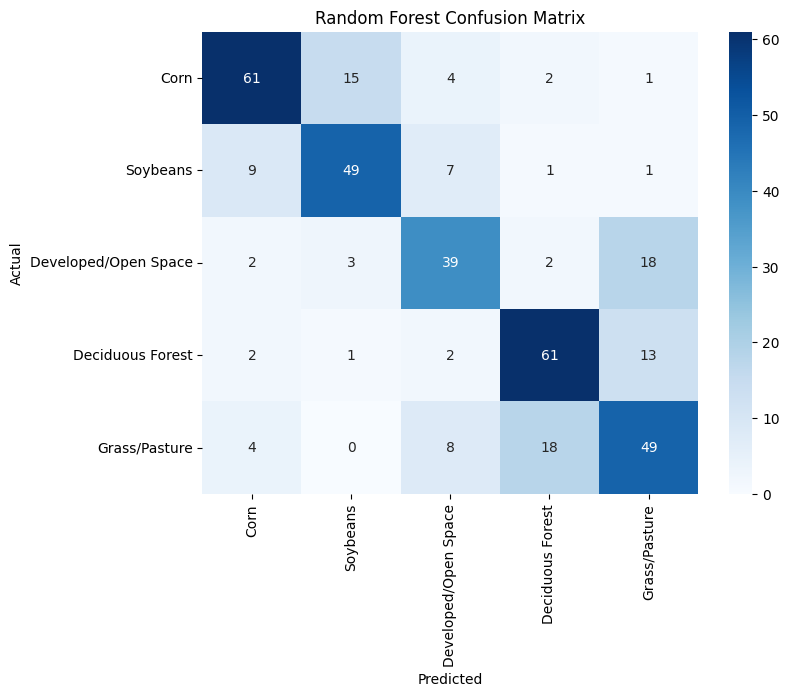

 99%|===================| 1846/1860 [00:40<00:00]       


SHAP bar plot for Random Forest (showing class index 1 if multi-class).


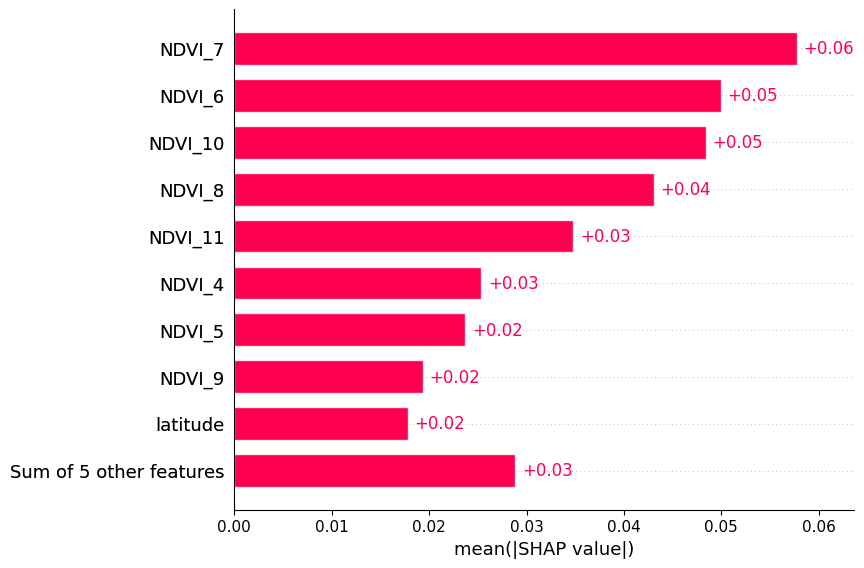


SHAP beeswarm plot for Random Forest (showing class index 1 if multi-class).


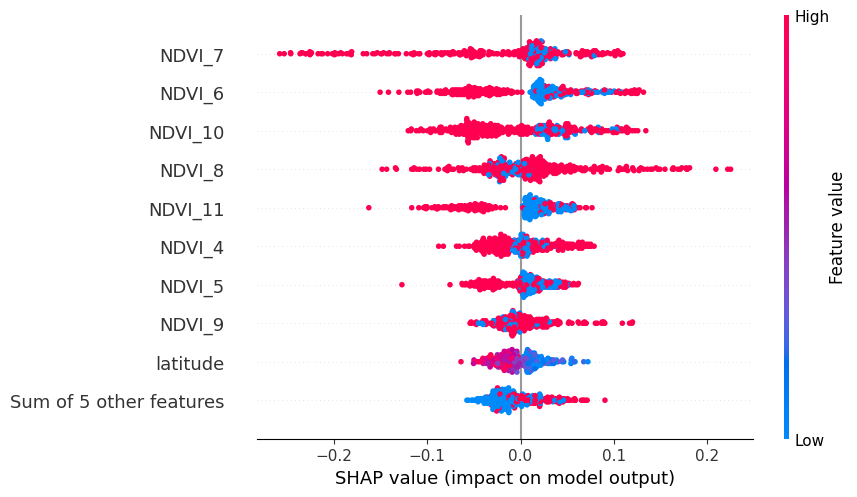

In [ ]:
# Without normalization:
results, cms, best_classifier = train_classifiers_on_dataset(
    df_train, df_test, predictor_props, label_property, le, class_labels, normalize=False
)

In [ ]:
# Without normalization:
results, cms, best_classifier = train_classifiers_on_dataset(
    df_train, df_test, predictor_props, label_property, le, class_labels, normalize=True, verbose=True
)

Encoded classes: [  1   5 121 141 176]


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:06:31] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.7097 |
+----------------+------------+
| Decision Tree  |     0.6022 |
+----------------+------------+
| SVM            |     0.2849 |
+----------------+------------+
| XGBoost        |     0.6694 |
+----------------+------------+
| Neural Network |     0.2581 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.7097


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Asset loaded successfully.
DataFrame created with shape: (1250, 18)
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Dataset Type   |   Corn |   Soybeans |   Developed/Open Space |   Deciduous Forest |   Grass/Pasture |
+================+========+============+========================+====================+=================+
| Full           |    250 |        250 |                    250 |                250 |             250 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Training       |    167 |        183 |                    186 |                171 |             171 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Test           |     83 |         67 |                     64 |                 79 |              79 |
+----------------+--------+------------+------------------------+--------------------+------

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:43:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.6935 |
+----------------+------------+
| Decision Tree  |     0.5941 |
+----------------+------------+
| SVM            |     0.2366 |
+----------------+------------+
| XGBoost        |     0.6694 |
+----------------+------------+
| Neural Network |     0.2392 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6935


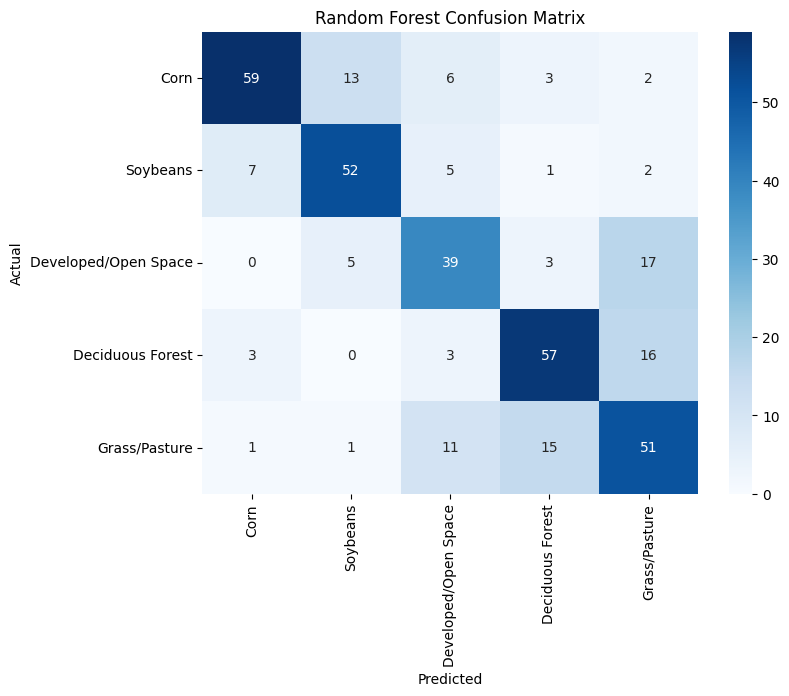

 99%|===================| 1837/1860 [00:38<00:00]       


SHAP bar plot for Random Forest (showing class index 1 if multi-class).


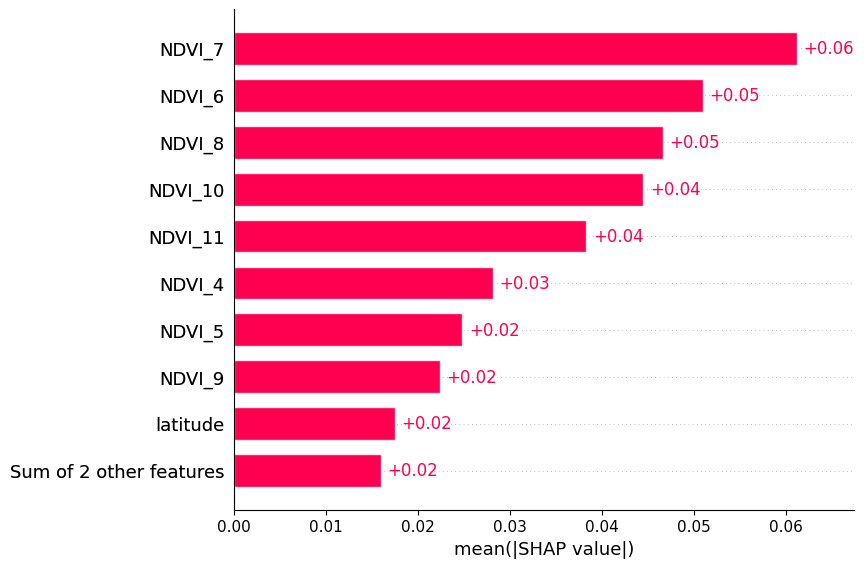


SHAP beeswarm plot for Random Forest (showing class index 1 if multi-class).


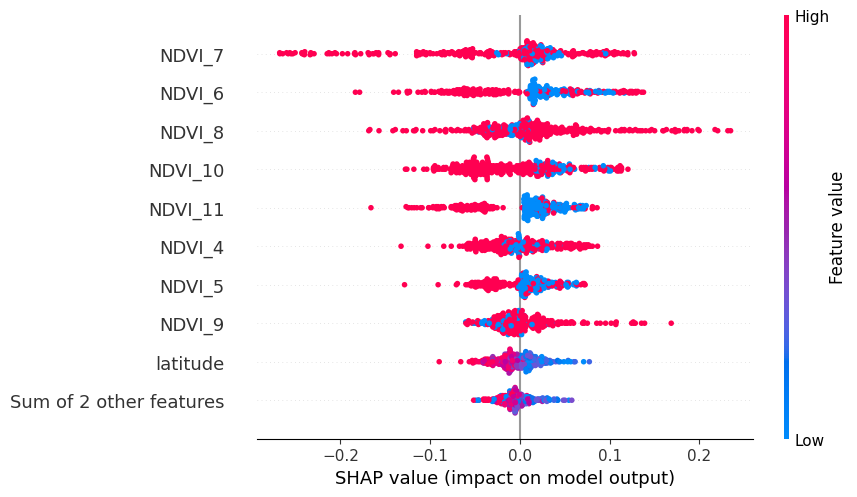

In [ ]:

# Define the reduced predictor columns: NDVI for months 4 to 8 plus latitude and longitude.
predictor_props_reduced = [f'NDVI_{m}' for m in range(4, 13)] + ['longitude', 'latitude']
label_property = 'crop_code'


# Load the asset and partition the dataset using the reduced predictor set.
df_all, df_train, df_test, le, class_labels = analyze_dataset(
    asset_path, predictor_props_reduced, label_property, top_5_crops
)

# Train classifiers on the reduced feature set without normalization.
results_reduced, cms_reduced, best_classifier_reduced = train_classifiers_on_dataset(
    df_train, df_test, predictor_props_reduced, label_property, le, class_labels, normalize=False
)

Asset loaded successfully.
DataFrame created with shape: (1250, 18)
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Dataset Type   |   Corn |   Soybeans |   Developed/Open Space |   Deciduous Forest |   Grass/Pasture |
+================+========+============+========================+====================+=================+
| Full           |    250 |        250 |                    250 |                250 |             250 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Training       |    167 |        183 |                    186 |                171 |             171 |
+----------------+--------+------------+------------------------+--------------------+-----------------+
| Test           |     83 |         67 |                     64 |                 79 |              79 |
+----------------+--------+------------+------------------------+--------------------+------

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [21:21:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


+----------------+------------+
| Classifier     |   Accuracy |
+================+============+
| Random Forest  |     0.6909 |
+----------------+------------+
| Decision Tree  |     0.5941 |
+----------------+------------+
| SVM            |     0.2151 |
+----------------+------------+
| XGBoost        |     0.6478 |
+----------------+------------+
| Neural Network |     0.2258 |
+----------------+------------+

Best Classifier: Random Forest with Accuracy: 0.6909


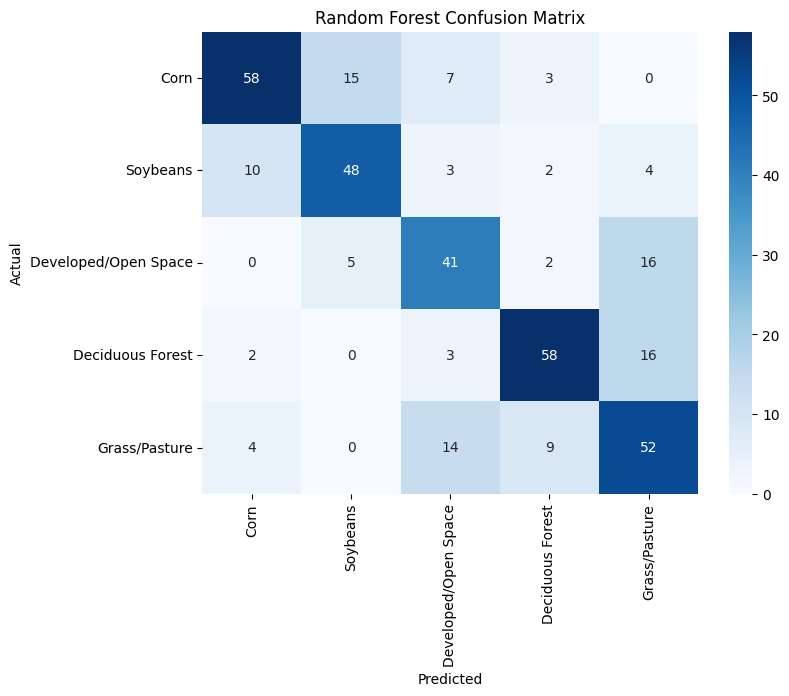

 99%|===================| 1839/1860 [00:34<00:00]       


SHAP bar plot for Random Forest (showing class index 1 if multi-class).


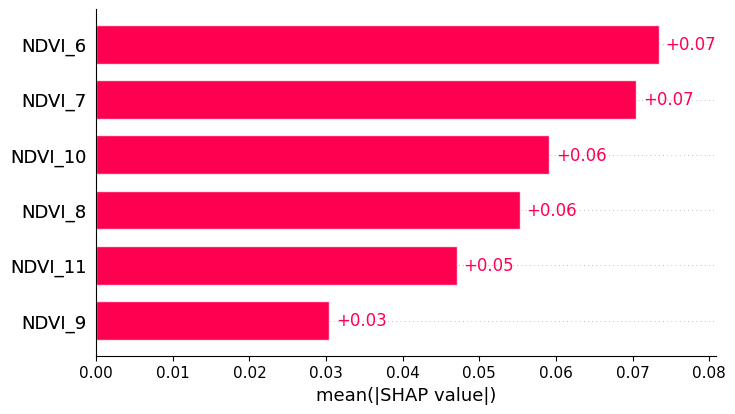


SHAP beeswarm plot for Random Forest (showing class index 1 if multi-class).


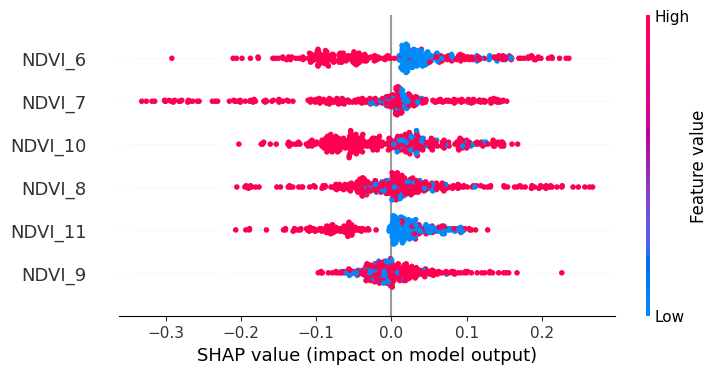

In [ ]:

# Define the reduced predictor columns: NDVI for months 4 to 8 plus latitude and longitude.
predictor_props_reduced = [f'NDVI_{m}' for m in range(6, 12)]
label_property = 'crop_code'


# Load the asset and partition the dataset using the reduced predictor set.
df_all, df_train, df_test, le, class_labels = analyze_dataset(
    asset_path, predictor_props_reduced, label_property, top_5_crops
)

# Train classifiers on the reduced feature set without normalization.
results_reduced, cms_reduced, best_classifier_reduced = train_classifiers_on_dataset(
    df_train, df_test, predictor_props_reduced, label_property, le, class_labels, normalize=False
)

In [ ]:
states = ['IA', 'IL']
years = ['2018', '2019', '2020']
num_points_per_crop = 200  # Adjusted for performance concerns
ndvi_months = [6, 7, 8, 9, 10, 11]  # NDVI months June-November

top_5_crops = {
    1: "Corn",
    5: "Soybeans",
    141: "Deciduous Forest",
    176: "Grass/Pasture",
    121: "Developed/Open Space"
}


for state_abbr in states:
    region_geom = get_state_geometry([state_abbr])

    for year in years:
        print(f"\nProcessing {state_abbr} for year {year}.")

        # Set NDVI collection for current state and year
        ndvi_collection = get_landsat_ndvi_collection(
            start_date=f'{year}-06-01',
            end_date=f'{year}-11-30',
            region=region_geom
        )

        # Initialize an empty FeatureCollection to store samples
        all_samples = ee.FeatureCollection([])

        # Perform stratified sampling for each crop
        for crop_code, crop_name in top_5_crops.items():
            print(f"  Sampling {crop_name}...")

            cdl_image = ee.Image(f'USDA/NASS/CDL/{year}').select('cropland').clip(region_geom)

            samples = sample_crop_locations(
                cdl_image=cdl_image,
                crop_code=crop_code,
                crop_name=crop_name,
                region_geom=region_geom,
                num_points=num_points_per_crop,
            )

            # Attach crop metadata
            samples = samples.map(lambda f: f.set({'crop_code': crop_code, 'crop_name': crop_name}))
            all_samples = all_samples.merge(samples)

        # Add NDVI for selected months and coordinates
        samples_with_ndvi = all_samples.map(
            lambda f: add_selected_monthly_ndvi(f, ndvi_collection, year)
        ).map(add_coordinates)

        # Add random column for train/test split later
        samples_with_ndvi = samples_with_ndvi.randomColumn('random', seed=42)

        # Define clear asset name
        asset_name = f"{state_abbr}_{num_points_per_crop}pts_{year}_stratified_NDVI6to11"

        # Export dataset as asset
        export_dataset_as_asset(samples_with_ndvi, region_name=asset_name, year=year)

        print(f"\n Asset export started: {asset_name}")


Processing IA for year 2018.
  Sampling Corn...
  Sampling Soybeans...
  Sampling Deciduous Forest...
  Sampling Grass/Pasture...
  Sampling Developed/Open Space...
Export task started for region IA_200pts_2018_stratified_NDVI6to11 for 2018.
Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IA_200pts_2018_stratified_NDVI6to11_2018

 Asset export started: IA_200pts_2018_stratified_NDVI6to11

Processing IA for year 2019.
  Sampling Corn...
  Sampling Soybeans...
  Sampling Deciduous Forest...
  Sampling Grass/Pasture...
  Sampling Developed/Open Space...
Export task started for region IA_200pts_2019_stratified_NDVI6to11 for 2019.
Monitor the task in the Earth Engine Code Editor's Tasks tab. Asset ID: projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_IA_200pts_2019_stratified_NDVI6to11_2019

 Asset export started: IA_200pts_2019_stratified_NDVI6to11

Processing IA for year 2020.
  Sampling Corn...

In [ ]:
# After exports are complete, load all assets:
asset_paths = [
    f"projects/toribiodiego-ece471/assets/ndvi_timeseries/NDVI_TS_{'Iowa' if s=='IA' else 'Illinois'}_{num_points}pts_{y}_stratified_NDVI6to11_{y}"
    for s in states for y in years
]

df_combined = pd.DataFrame()
for path in asset_paths:
    print(f"Loading asset: {path}")
    fc = ee.FeatureCollection(path)
    df_asset = fc_to_df(fc)
    df_asset['source'] = path.split('/')[-1]  # Track dataset origin
    df_combined = pd.concat([df_combined, df_asset], ignore_index=True)

print(f"Combined DataFrame shape: {df_combined.shape}")


# Clean and split data
df_combined.dropna(subset=predictor_props + [label_property], inplace=True)

# Unified random split
np.random.seed(42)
df_combined['random'] = np.random.rand(len(df_combined))

df_train = df_combined[df_combined['random'] < 0.7]
df_test = df_combined[df_combined['random'] >= 0.7]

print("Train shape:", df_train.shape, "Test shape:", df_test.shape)

# Label encoding
le = LabelEncoder()
le.fit(df_train[label_property].astype(int))

class_labels = [top_5_crops[int(c)] for c in le.inverse_transform(range(len(le.classes_)))]


In [ ]:
# Without normalization:
results, cms, best_classifier = train_classifiers_on_dataset(
    df_train,
    df_test,
    predictor_props,
    label_property,
    le,
    class_labels,
    normalize=False,
    verbose=True  # Set to False if you prefer less output
)


### Task 3.1: Model Development

Develop a classification model to predict crop type using satellite imagery and temporal vegetation data as input features. The model should be trained on the sampled points from Task 2 and output predictions for the 5 major crops plus a "other" class.

Key Requirements:

- Use sampled crop points (or sampling script) from Task 2 as training data.
- You may want to include more samples for the model than what was created in Task 2.
- Input features must include, but are not limited to, Landsat surface reflectance imagery from the growing season.
- Incorporate temporal vegetation indices like NDVI time series.
- Output predictions for the 5 major crops identified in Task 1 plus an "other" class. This "other" class could be expanded into multiple classes if deemed useful.
- Document modeling methodology including:
  - Model type, input features, training approach
  - Any data preprocessing/augmentation
  - Tools and libraries used
  - Modeling can be fully in GEE or combine external tools like Scikit-learn, Tensorflow, etc.

Remember that ideally, we are attempting to build a model that does NOT require data across the entire year. Put another way, the less data our model needs about the growing season to make a good prediction about the crop type, the better!

If this proves challenging, start by using an entire year's worth of data for your model (like CDL). Achieving good performance with your classifier with a full year's worth of data will earn you full credit, and extra credit will be given to in-season prediction.

### Task 3.2: Model Testing

Validate the performance of the developed crop classification model using accuracy metrics calculated on a held-out test set. This test set can be created with the same sampling strategy from before, but should be created indepdently of the training and validation data (e.g. not be seen by the model at all before testing).

Key Requirements:

- Reserve 10-20% of the training data to hold out for testing.
- Calculate precision, recall and F1 score metrics on the test set.
- Generate a confusion matrix showing per-class accuracies and errors.
- Analyze the results - where does the model perform well or poorly?
- The validation script must enable testing on new unseen data.

Interpret what the results imply about the real-world viability of the model. It's okay if you don't think your model is anywhere nearly as good as CDL is. Identify areas for improvement and potential next steps to further improve performance. Finally, document insights gained from the validation process and analysis of the results.

### Task 3.3: Model Deployment

We're at the end, now it's time to see how our model does over an entire county! Apply the developed crop classification model to full counties to create prediction maps and visually compare against ground truth data.

Key Requirements:

- Script should take any county as an input and produce an output classification.
- Specifically generate output classification results for two counties: (1) Crawford County, Iowa (2) Grant County, Wisconsin. (NOTE we did not train at all in Wisconsin!)
- Run the model over all the pixels of each county.
- Output crop classification maps with predictions at 30 meter resolution.
- Visually compare the model outputs to the Cropland Data Layer (CDL).
- Document any data exports or external processing required.

If your model was built entirely in GEE (recommended), deployment should be straightforward. If your model however was built outside of GEE and you had to export lots of data to run your mode, you may need to ingest results back into GEE (if needed) for visualization and comparison.

Analyze similarities and differences between your model output and the CDL. Do they line up at all? Is your approach viable for real-world deployment? How do the results differ when looked at a much larger geographic scale compared to the test set?

## Tips
- Start small and iterate! Begin by testing workflows on small counties before expanding to the full two states. This will help identify any issues early.
- Leverage the vast data in GEE! The Cropland Data Layer and Landsat imagery on GEE provide a rich dataset. But feel free to incorporate any other relevant data sources available.
- Plan exporting data from GEE! For large regional analysis, you may need to batch export preprocessed data to your local environment for modeling.
- Store off computationally heavy intermediate results! you may want to store intermediate FeatureCollections and Images as GEE assets such that you do not have to dynamically re-create them every time.
- Documentation is key! Thoroughly document your methodology, thought process, experiments, and results. This transparency is important for full credit.
- Visualizations tell a story! Use insightful visuals like time series plots and comparison maps to showcase your findings.
- There are many valid approaches! This assignment is open-ended by design. There are many "correct" ways to analyze the data and build models.
- Ask questions early! Please reach out if you need any guidance or get stuck. I'm happy to provide clarification and nudges in the right direction.